# Định Hướng Phát Triển Mô Hình Nhận Diện Mức Độ Trầm Cảm (Depression Detection)

Dựa vào dataset (`Depression_Severity_Levels_Dataset.csv`), bài toán của chúng ta là **Phân loại văn bản đa lớp (Multiclass Text Classification)**. Các nhãn (labels) bao gồm các mức độ: `minimum`, `mild`, `moderate`, `severe`.

## Hướng đi đề xuất (Workflow)

### 1. Khám phá dữ liệu (Exploratory Data Analysis - EDA)
- Đọc dữ liệu và xem xét tổng quan.
- Kiểm tra sự phân bố của các nhãn xem có hiện tượng mất cân bằng dữ liệu (Class Imbalance) hay không.
- Phân tích chiều dài văn bản (word count) trung bình theo từng nhãn để xem mức độ dài ngắn có liên quan tới severity không.
- Rút trích các từ vựng phổ biến nhất cho mỗi nhãn (dùng WordCloud).

Đang đọc dữ liệu từ: Depression_Severity_Levels_Dataset.csv
Kích thước dữ liệu: (41873, 2)


,text,label
0,"He said he had not felt that way before, sugge...",mild
1,"Hey there r/assistance, Not sure if this is th...",minimum
2,My mom then hit me with the newspaper and it s...,minimum
3,"until i met my new boyfriend, he is amazing, h...",mild
4,October is Domestic Violence Awareness Month a...,moderate


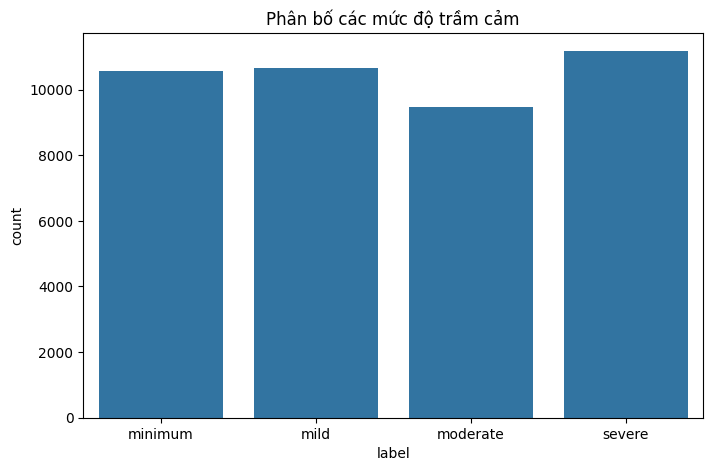

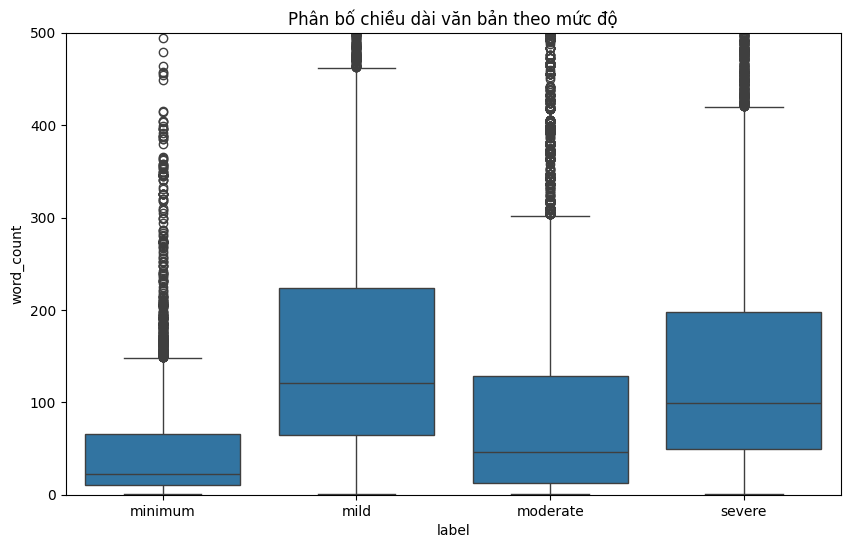

In [1]:
import os
# Tắt Weights & Biases để tránh bị treo khi chạy ngầm trên Kaggle
os.environ["WANDB_DISABLED"] = "true"

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Tìm đường dẫn đúng của file dữ liệu (hỗ trợ cả chạy ở máy cá nhân và trên Kaggle)
csv_path = 'Depression_Severity_Levels_Dataset.csv'
if not os.path.exists(csv_path):
    # Tự động quét tìm file trong thư mục input của Kaggle
    for dirname, _, filenames in os.walk('/kaggle/input'):
        for filename in filenames:
            if filename == 'Depression_Severity_Levels_Dataset.csv':
                csv_path = os.path.join(dirname, filename)
                break

print(f"Đang đọc dữ liệu từ: {csv_path}")
df = pd.read_csv(csv_path)
print("Kích thước dữ liệu:", df.shape)
display(df.head())

# Kiểm tra phân bố nhãn
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='label', order=['minimum', 'mild', 'moderate', 'severe'])
plt.title('Phân bố các mức độ trầm cảm')
plt.show()

# Phân tích chiều dài văn bản
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='label', y='word_count', order=['minimum', 'mild', 'moderate', 'severe'])
plt.title('Phân bố chiều dài văn bản theo mức độ')
plt.ylim(0, 500) # Giới hạn hiển thị để dễ nhìn
plt.show()


### 2. Tiền xử lý dữ liệu (Data Preprocessing)
- Loại bỏ URLs, HTML tags, ký tự đặc biệt, số, và dấu câu.
- Chuyển đổi văn bản về chữ thường (lowercase).
- Tokenization (tách từ).
- Xóa Stop words (những từ quá phổ biến không mang nhiều ý nghĩa).
- Lemmatization hoặc Stemming (đưa từ về dạng gốc).

In [2]:
from IPython.display import display
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

stop_words = set(stopwords.words('english'))
# Giữ lại các từ phủ định và từ nhấn mạnh vì chúng quan trọng cho phân loại cảm xúc
important_words = {'not', 'no', 'nor', 'never', 'none', 'neither', 'cannot', 'very', 'too', 'just', 'only', 'but'}
contractions = {"isn't", "aren't", "wasn't", "weren't", "haven't", "hasn't", "hadn't", "won't", "wouldn't", "don't", "doesn't", "didn't", "can't", "couldn't", "shouldn't", "mightn't", "mustn't"}
important_words.update(contractions)
stop_words = stop_words - important_words

lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    # Chuyển thành chữ thường
    text = text.lower()
    # Loại bỏ URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Loại bỏ HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Loại bỏ ký tự đặc biệt, số và dấu câu
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenization và loại bỏ stop words, lemmatization
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(tokens)

print("Bắt đầu tiền xử lý dữ liệu...")
df['clean_text'] = df['text'].apply(preprocess_text)
print("Hoàn thành!")
display(df[['text', 'clean_text']].head())


Bắt đầu tiền xử lý dữ liệu...
Hoàn thành!


,text,clean_text
0,"He said he had not felt that way before, sugge...",said not felt way suggeted go rest trigger ahe...
1,"Hey there r/assistance, Not sure if this is th...",hey rassistance not sure right place post but ...
2,My mom then hit me with the newspaper and it s...,mom hit newspaper shocked would know dont like...
3,"until i met my new boyfriend, he is amazing, h...",met new boyfriend amazing kind sweet good stud...
4,October is Domestic Violence Awareness Month a...,october domestic violence awareness month dome...


### 3. Trích xuất đặc trưng (Feature Extraction)
- **Truyền thống:** Sử dụng `TF-IDF` (Term Frequency-Inverse Document Frequency).
- **Hiện đại:** Dùng Word Embeddings (Word2Vec, FastText) hoặc Contextual Embeddings (BERT, RoBERTa).

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Tách dữ liệu Train / Test trên dataframe gốc để giữ nguyên index
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

X_train_clean = df_train['clean_text']
X_test_clean = df_test['clean_text']

X_train_raw = df_train['text'].astype(str)
X_test_raw = df_test['text'].astype(str)

y_train = df_train['label']
y_test = df_test['label']

# Khởi tạo và fit TF-IDF (sử dụng clean_text cho ML Models)
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train_clean)
X_test_tfidf = tfidf.transform(X_test_clean)

print("Kích thước tập train (TF-IDF):", X_train_tfidf.shape)
print("Kích thước tập test (TF-IDF):", X_test_tfidf.shape)


Kích thước tập train (TF-IDF): (33498, 5000)
Kích thước tập test (TF-IDF): (8375, 5000)


### 4. Lựa chọn & Xây dựng mô hình (Modeling)
- **Mức cơ bản (Baseline):** Các mô hình Machine Learning cổ điển như Support Vector Machine, LightGBM kết hợp với đặc trưng TF-IDF.
- **Mức nâng cao (Deep Learning):** Mạng nơ-ron Bi-LSTM kết hợp FastText.
- **State-of-the-Art (Khuyên dùng):** Fine-tune mô hình pre-trained Transformers như `RoBERTa`.

In [4]:
from sklearn.svm import LinearSVC
import time

print("Đang huấn luyện mô hình SVM (TF-IDF)...")
start_time = time.time()
# Tối ưu: Thêm dual=False vì số mẫu > số đặc trưng
svm_model = LinearSVC(class_weight='balanced', random_state=42, max_iter=2000, dual=False)
svm_model.fit(X_train_tfidf, y_train)
y_pred_svm = svm_model.predict(X_test_tfidf)
print(f"Hoàn thành SVM trong {time.time() - start_time:.2f} giây!")


Đang huấn luyện mô hình SVM (TF-IDF)...
Hoàn thành SVM trong 5.67 giây!


In [5]:
import lightgbm as lgb
import time

print("Đang huấn luyện mô hình LightGBM (TF-IDF)...")
start_time = time.time()
lgb_model = lgb.LGBMClassifier(
    objective='multiclass', 
    num_class=4, 
    class_weight='balanced', 
    random_state=42, 
    n_jobs=-1
)
lgb_model.fit(X_train_tfidf, y_train)
y_pred_lgb = lgb_model.predict(X_test_tfidf)
print(f"Hoàn thành LightGBM trong {time.time() - start_time:.2f} giây!")


Đang huấn luyện mô hình LightGBM (TF-IDF)...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.663370 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 340695
[LightGBM] [Info] Number of data points in the train set: 33498, number of used features: 4984
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
Hoàn thành LightGBM trong 50.61 giây!


C:\Users\toanl\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### Deep Learning: Bi-LSTM + FastText (hoặc Embedding layer)

In [8]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print("Chuẩn bị dữ liệu cho Bi-LSTM...")
# Encode labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)
num_classes = len(label_encoder.classes_)

# Tính toán class_weights để xử lý mất cân bằng dữ liệu
weights = compute_class_weight('balanced', classes=np.unique(y_train_encoded), y=y_train_encoded)
class_weights_dict = dict(enumerate(weights))

# Tokenization cho LSTM
max_words = 15000
max_len = 150
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train_raw)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train_raw), maxlen=max_len)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test_raw), maxlen=max_len)

# Tải FastText Embeddings (Ở đây dùng Embedding ngẫu nhiên để minh hoạ)
embedding_dim = 300

print("Xây dựng mô hình Bi-LSTM...")
bilstm_model = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(64, return_sequences=True)),
    Bidirectional(LSTM(32)),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

bilstm_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
bilstm_model.summary()

# Tối ưu: Thêm Early Stopping và ModelCheckpoint để tránh overfit và lưu model tốt nhất
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
checkpoint = ModelCheckpoint('./best_bilstm_model.keras', monitor='val_accuracy', save_best_only=True)

print("Đang huấn luyện Bi-LSTM...")
# Tối ưu: thêm class_weight và callbacks
history = bilstm_model.fit(
    X_train_seq, 
    y_train_encoded, 
    epochs=10, 
    batch_size=128, 
    validation_split=0.1, 
    verbose=1,
    class_weight=class_weights_dict,
    callbacks=[early_stop, checkpoint]
)

# Dự đoán
y_pred_bilstm_prob = bilstm_model.predict(X_test_seq)
y_pred_bilstm_encoded = np.argmax(y_pred_bilstm_prob, axis=1)
y_pred_bilstm = label_encoder.inverse_transform(y_pred_bilstm_encoded)
print("Hoàn thành Bi-LSTM!")


Chuẩn bị dữ liệu cho Bi-LSTM...


AttributeError: 'float' object has no attribute 'lower'

### State-of-the-Art Transformer: RoBERTa

In [ ]:
import torch
from torch.utils.data import Dataset
from transformers import RobertaTokenizer, RobertaForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
import numpy as np
from sklearn.metrics import accuracy_score

print("Chuẩn bị dữ liệu cho RoBERTa...")
model_name = "roberta-base"
try:
    roberta_tokenizer = RobertaTokenizer.from_pretrained(model_name)
except:
    print("Cần kết nối mạng để tải mô hình hoặc cài đặt thư viện transformers.")

class DepressionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

if 'label_encoder' in locals():
    y_train_rob = label_encoder.transform(y_train)
    y_test_rob = label_encoder.transform(y_test)

    train_dataset = DepressionDataset(X_train_raw, y_train_rob, roberta_tokenizer)
    test_dataset = DepressionDataset(X_test_raw, y_test_rob, roberta_tokenizer)

    print("Khởi tạo mô hình RoBERTa...")
    roberta_model = RobertaForSequenceClassification.from_pretrained(model_name, num_labels=num_classes)

    # Tối ưu: Thêm fp16=True, early stopping config, và chỉnh lại learning_rate
    training_args = TrainingArguments(
        output_dir='./results',
        num_train_epochs=5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_dir='./logs',
        learning_rate=2e-5,
        fp16=True,
        load_best_model_at_end=True,
        metric_for_best_model="accuracy"
    )

    def compute_metrics(pred):
        labels = pred.label_ids
        preds = pred.predictions.argmax(-1)
        acc = accuracy_score(labels, preds)
        return {'accuracy': acc}

    trainer = Trainer(
        model=roberta_model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

    print("Đang huấn luyện RoBERTa...")
    trainer.train()
    
    print("Dự đoán với RoBERTa...")
    predictions = trainer.predict(test_dataset)
    y_pred_rob_encoded = np.argmax(predictions.predictions, axis=1)
    y_pred_roberta = label_encoder.inverse_transform(y_pred_rob_encoded)


Chuẩn bị dữ liệu cho RoBERTa...
Khởi tạo mô hình RoBERTa...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Đang huấn luyện RoBERTa...


C:\Users\toanl\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss


### 5. Đánh giá mô hình (Evaluation)
- Dùng **Accuracy, Precision, Recall, F1-Score**.
- Do các lớp có thể không cân bằng, cần chú ý đặc biệt tới **Macro F1-Score** hoặc **Weighted F1-Score**.
- Sử dụng **Confusion Matrix** để kiểm tra xem mô hình có hay bị nhầm lẫn giữa các mức độ liền kề không.

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def evaluate_model(y_true, y_pred, model_name):
    print(f"=== Đánh giá mô hình {model_name} ===")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))
    
    cm = confusion_matrix(y_true, y_pred, labels=['minimum', 'mild', 'moderate', 'severe'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['minimum', 'mild', 'moderate', 'severe'])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

# Đánh giá SVM
if 'y_pred_svm' in locals():
    evaluate_model(y_test, y_pred_svm, "SVM")

# Đánh giá LightGBM
if 'y_pred_lgb' in locals():
    evaluate_model(y_test, y_pred_lgb, "LightGBM")

# Đánh giá Bi-LSTM
if 'y_pred_bilstm' in locals():
    evaluate_model(y_test, y_pred_bilstm, "Bi-LSTM")

# Đánh giá RoBERTa
if 'y_pred_roberta' in locals():
    evaluate_model(y_test, y_pred_roberta, "RoBERTa")
